In [11]:
import sys
import os
sys.path.append(os.path.abspath("src"))

In [12]:
import pandas as pd
from src.limpieza_datos import ejecutar_limpieza
from src.conexiones_grafo import ejecutar_conexiones
from src.grafo import construir_grafo_desde_rutas
from src.dijkstra import buscar_hospital_adecuado
from src.prim import ejecutar_prim
from src.kdtree import construir_kdtree_hospitales, buscar_hospitales_en_radio
from src.geoespacial import preparar_candidatos_geoespaciales
from src.visualizaciones import (
    visualizar_ruta_dijkstra,
    visualizar_hospitales_cercanos,
    imprimir_resultado_dijkstra,
    imprimir_resultado_prim,
    visualizar_grafo_rutas_hospitalarias,
    visualizar_grafo_hospitales_completo,
    visualizar_mst_geografico,
)

In [13]:
#Limpieza de datos:
datos = ejecutar_limpieza()

hospitales = datos["hospitales"]
capacidades = datos["capacidades"]
emergencias = datos["emergencias"]

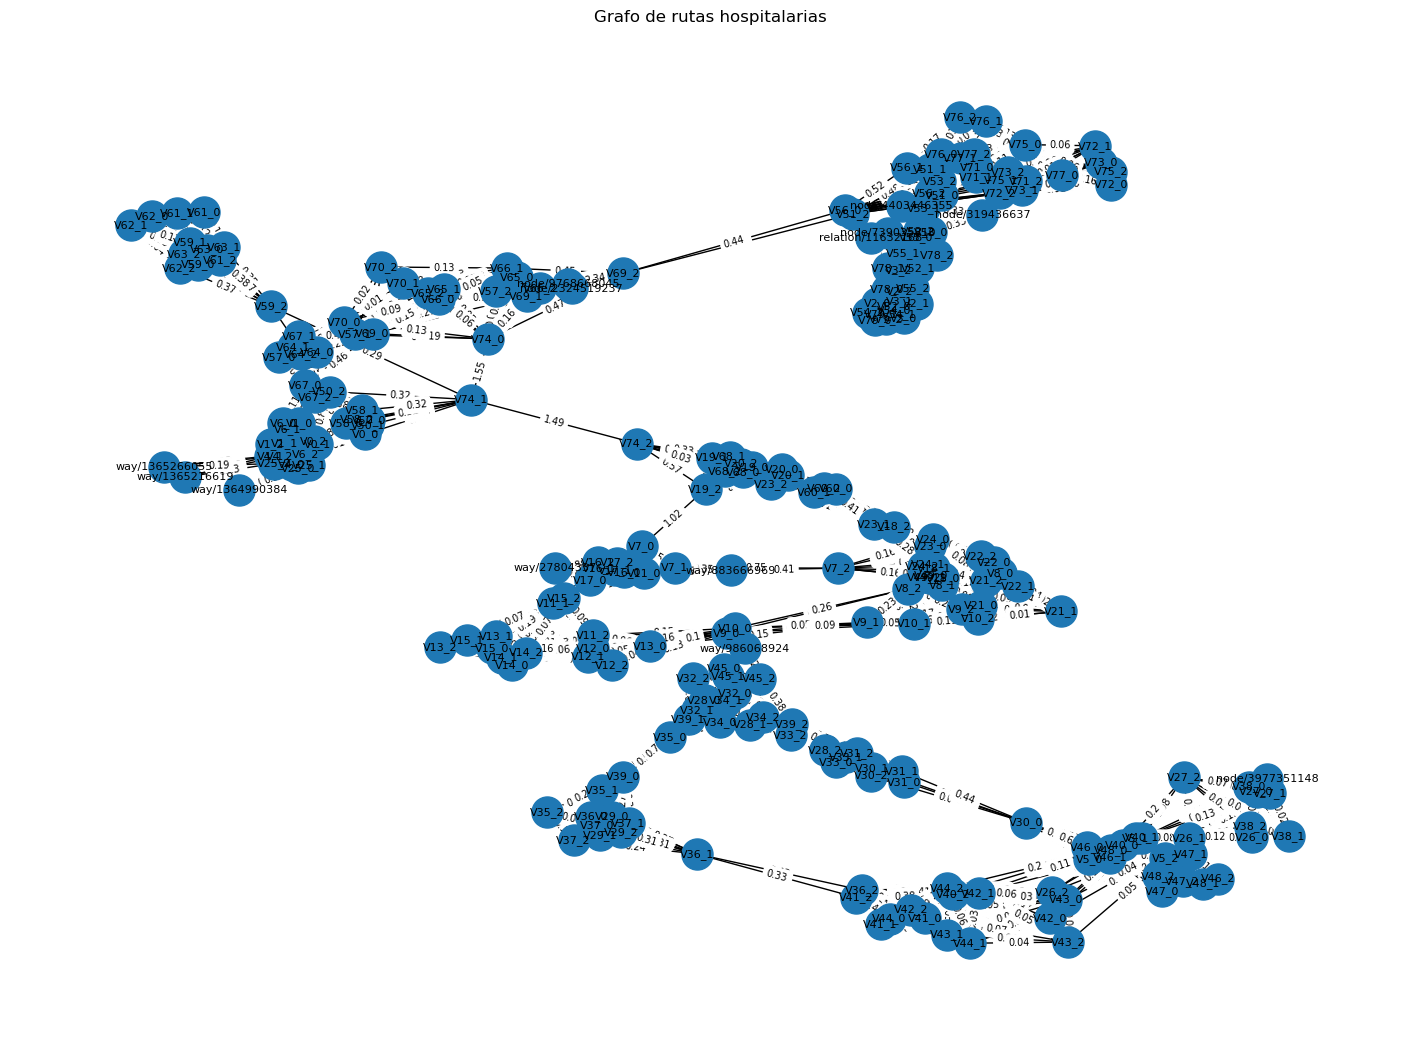

In [14]:
#Construcción de rutas y grafos

rutas_completas = ejecutar_conexiones()
grafo = construir_grafo_desde_rutas(rutas_completas)
visualizar_grafo_rutas_hospitalarias(grafo)

In [15]:
#definir emergencia: 
emergencia = datos["emergencias"].iloc[0]

In [16]:
# busca hospitales cercanos para un radio r
r = 5
kdtree = construir_kdtree_hospitales(hospitales)

hospitales_cercanos, capacidades_filtradas = preparar_candidatos_geoespaciales(
    datos["hospitales"],
    datos["capacidades"],
    emergencia,
    radio_km = r,
)

print(hospitales_cercanos)
print (capacidades_filtradas)

[{'id_hospital': 'way/883666969', 'hospital': 'Hospital General Dr. Fernando Quiroz Gutiérrez ISSSTE', 'lat': 19.3943867, 'lon': -99.1942231, 'distancia_km': 0.556, 'datos_hospital': {'id_osm': 'way/883666969', 'nombre': 'Hospital General Dr. Fernando Quiroz Gutiérrez ISSSTE', 'lat': 19.3943867, 'lon': -99.1942231, 'especialidades_osm': 'general;cardiologia;radiologia;intensivo', 'emergencias': 'yes', 'institucion': 'ISSSTE'}}, {'id_hospital': 'way/27804337', 'hospital': 'Centro Médico ABC', 'lat': 19.4002123, 'lon': -99.2039979, 'distancia_km': 1.499, 'datos_hospital': {'id_osm': 'way/27804337', 'nombre': 'Centro Médico ABC', 'lat': 19.4002123, 'lon': -99.2039979, 'especialidades_osm': 'general;cardiologia;pediatria;ginecologia;emergencia;cirugia;cardiologia;oncologia;cardiologia;radiologia;intensivo;interno', 'emergencias': 'yes', 'institucion': None}}, {'id_hospital': 'way/1364990384', 'hospital': None, 'lat': 19.360337, 'lon': -99.1765089, 'distancia_km': 4.361, 'datos_hospital': {

In [17]:
# buscar hospital optimo

resultado_dijkstra = buscar_hospital_adecuado(
    grafo,
    emergencia,
    capacidades_filtradas,
)

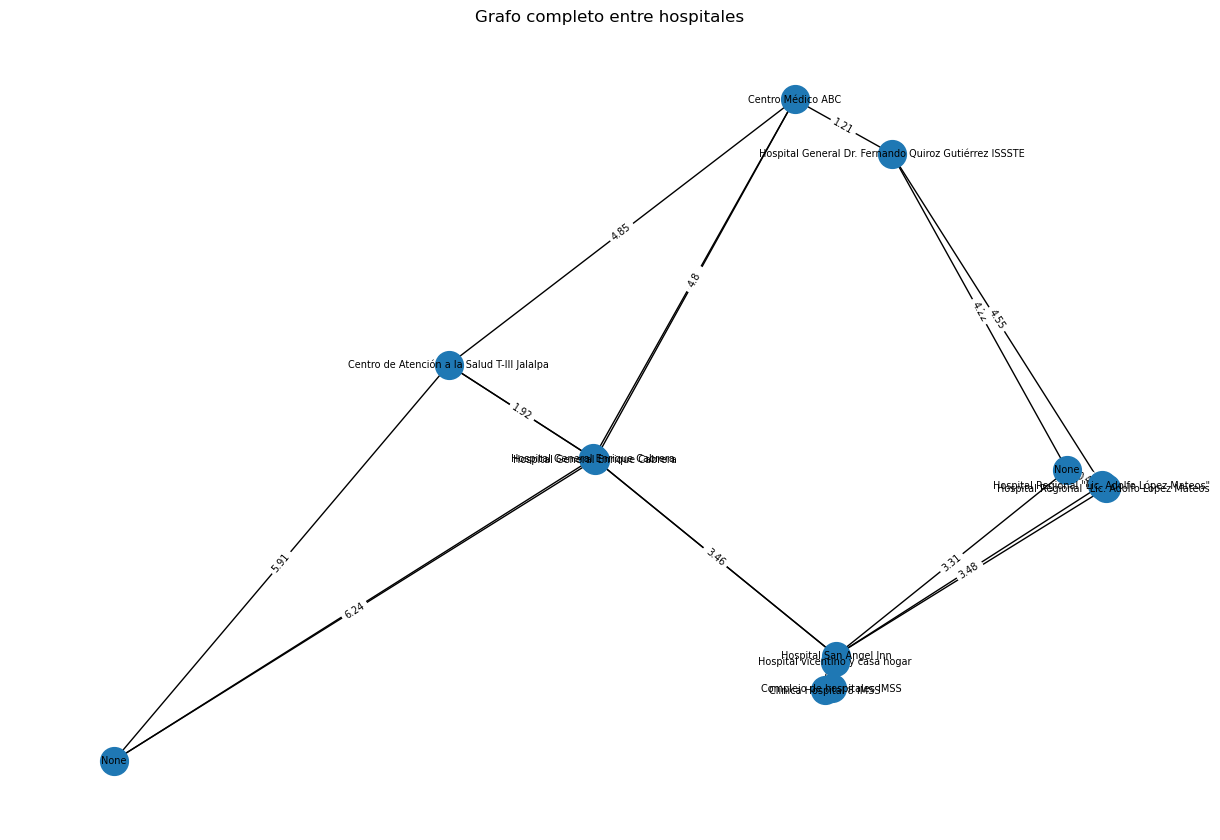

In [18]:
resultado_prim = ejecutar_prim(hospitales)

visualizar_grafo_hospitales_completo(
    resultado_prim["grafo_hospitales"],
    hospitales,
)

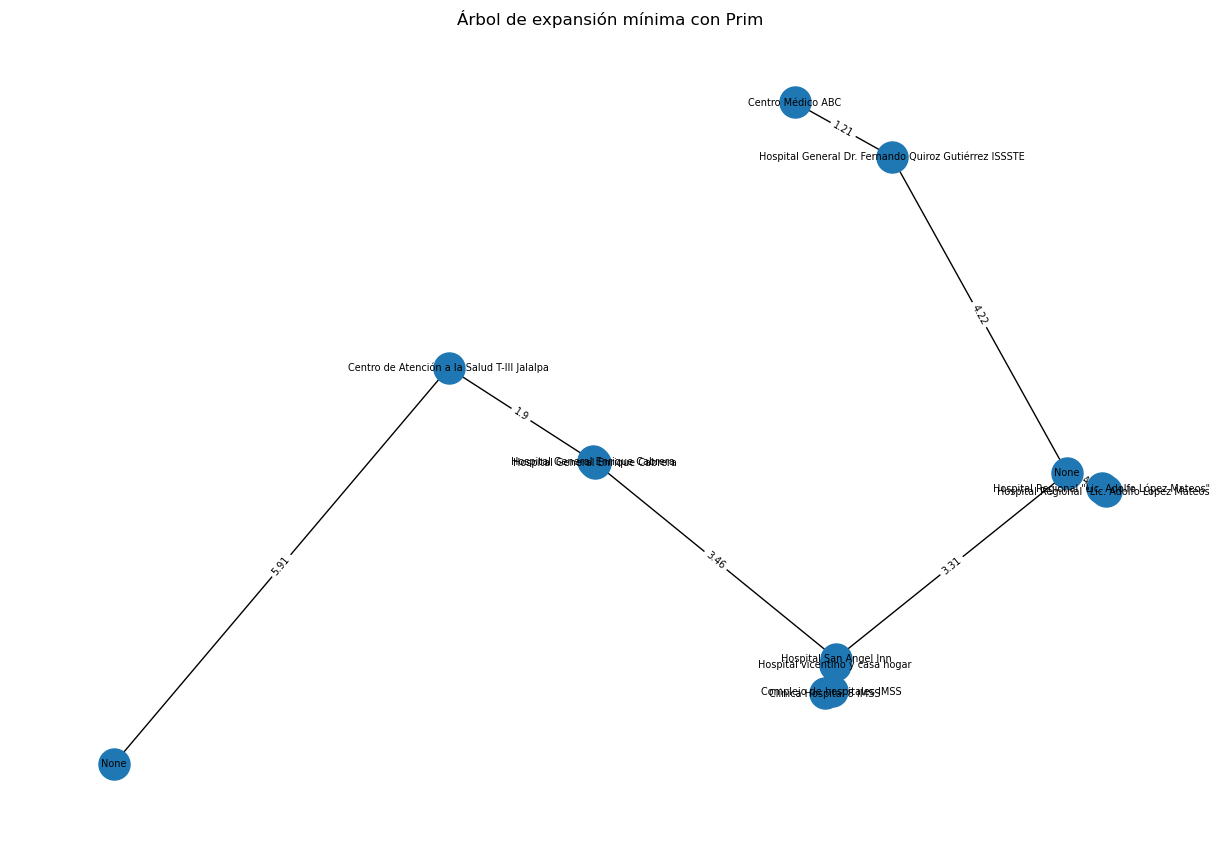

In [19]:
visualizar_mst_geografico(
    resultado_prim["padre"],
    resultado_prim["llave"],
    hospitales,
)


===== RESULTADO DIJKSTRA =====
Hospital: Hospital Regional "Lic. Adolfo López Mateos"
Especialidad: urgencias
Camas disponibles: 9
Costo de ruta: 5.819
Ruta:
 -> V8_0
 -> V23_0
 -> V23_1
 -> V60_2
 -> V68_0
 -> V74_2
 -> V74_1
 -> V0_0
 -> V0_2
 -> V4_1
 -> way/1365216619


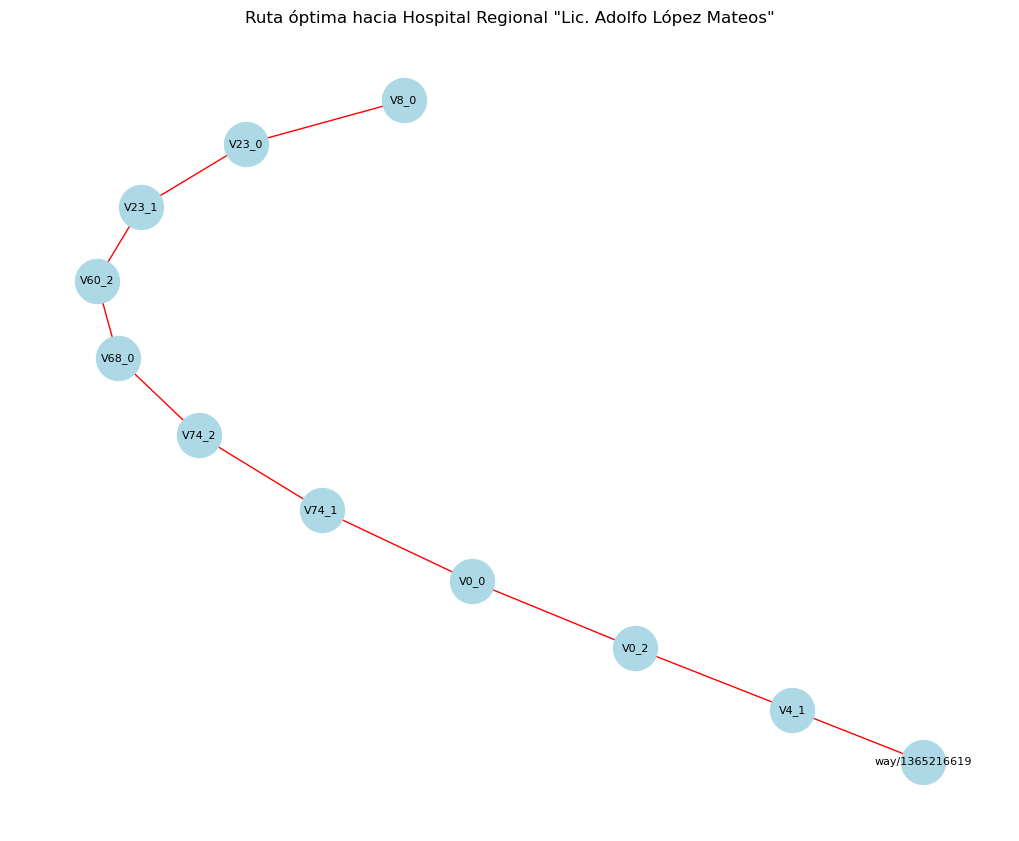

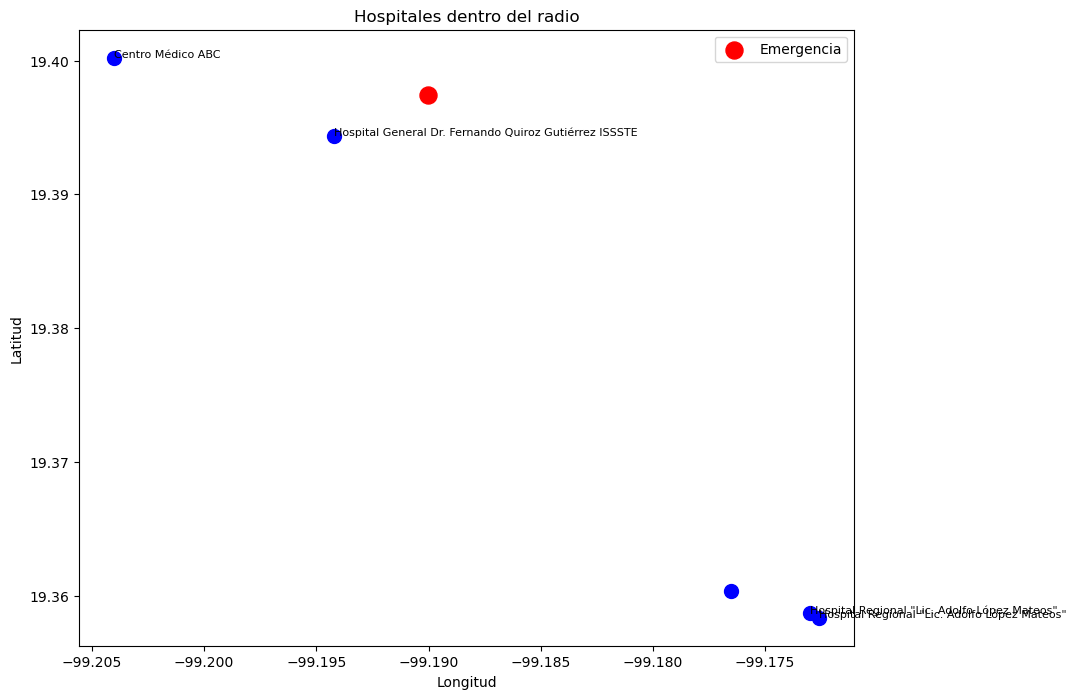


===== RESULTADO PRIM =====
Costo total MST: 20.976

Aristas MST:
               origen          destino  costo
0   relation/11632168   node/739035810  0.077
1   relation/11632168  node/4403446355  0.321
2     node/4403446355   node/319436637  0.075
3       way/883666969     way/27804337  1.213
4      way/1364990384    way/883666969  4.218
5     node/9768668045  node/2324519237  0.025
6      node/319436637  node/9768668045  3.463
7      node/319436637   way/1364990384  3.306
8      way/1364990384   way/1365266055  0.409
9     node/2324519237    way/986068924  1.897
10     way/1365266055   way/1365216619  0.058
11      way/986068924  node/3977351148  5.914


In [20]:
#imprimir resultados y visualizar grafos:

imprimir_resultado_dijkstra(resultado_dijkstra)
visualizar_ruta_dijkstra(resultado_dijkstra)
visualizar_hospitales_cercanos(hospitales_cercanos,emergencia,)
imprimir_resultado_prim(resultado_prim)